# Sequence Classification: Two-Channel Spectral Input

This notebook demonstrates a neural network classifier that predicts amino acids using a **two-channel input** approach.

## Task Overview
- **Input**: Two-channel signal of shape (2, 1023)
- **Output**: Predict the target amino acid (6 classes)

## Data Types
1. **Dipeptide pairs**: (dipeptide XY, amino acid X) → predict Y
2. **Single amino acids**: (amino acid X, zeros) → predict X

## Key Difference from Differential Approach
- **Differential**: Computes `XY - X` → 1-channel input
- **Two-Channel**: Concatenates `[signal1, signal2]` → 2-channel input, letting the model learn the relationship

## Available Data
- Dipeptides: combinations of {A, D, F, G, R, S}
- Single amino acids: {A, D, F, G, R, S}
- 6 target classes: A (Alanine), D (Aspartic acid), F (Phenylalanine), G (Glycine), R (Arginine), S (Serine)

## Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using device: cuda


## Constants and Mappings

In [2]:
# Target amino acid classes (6 classes)
AMINO_ACID_CODES = ['A', 'D', 'F', 'G', 'R', 'S']
CODE_TO_IDX = {code: idx for idx, code in enumerate(AMINO_ACID_CODES)}
IDX_TO_CODE = {idx: code for code, idx in CODE_TO_IDX.items()}

# Full names for display
CODE_TO_NAME = {
    'A': 'Alanine',
    'D': 'Aspartic acid',
    'F': 'Phenylalanine',
    'G': 'Glycine',
    'R': 'Arginine',
    'S': 'Serine'
}

# Mapping from single-letter code to folder name in aminoacids directory
AMINOACID_FOLDER_MAPPING = {
    'A': 'L-Alanine',
    'D': 'L-Aspartic acid',
    'F': 'L-Phenylalanine',
    'G': 'Glycine',
    'R': 'L-Arginine',
    'S': 'L-Serine'
}

# Data loading parameters
MIN_SPECTRA = 5  # Minimum spectra to include (will be upsampled to TARGET_SPECTRA)
TARGET_SPECTRA = 200  # Exact number of spectra to load per case

print(f'Target classes: {AMINO_ACID_CODES}')
print(f'Class mapping: {CODE_TO_IDX}')
print(f'Target spectra per case: {TARGET_SPECTRA}')

Target classes: ['A', 'D', 'F', 'G', 'R', 'S']
Class mapping: {'A': 0, 'D': 1, 'F': 2, 'G': 3, 'R': 4, 'S': 5}
Target spectra per case: 200


## Data Loading

In [3]:
# Data directories
dipeptide_dir = Path('./data/processed/dipeptides')
aminoacid_dir = Path('./data/processed/aminoacids')

def resample_to_target(spectra, target_count, random_state=42):
    """Resample spectra to exactly target_count samples.
    
    If spectra > target_count: downsample without replacement
    If spectra < target_count: upsample with replacement
    
    Args:
        spectra: numpy array of shape (n_samples, seq_length)
        target_count: desired number of samples
        random_state: random seed for reproducibility
    
    Returns:
        resampled spectra of shape (target_count, seq_length)
    """
    np.random.seed(random_state)
    n_samples = len(spectra)
    
    if n_samples == target_count:
        return spectra.copy()
    elif n_samples > target_count:
        # Downsample without replacement
        indices = np.random.choice(n_samples, target_count, replace=False)
    else:
        # Upsample with replacement
        indices = np.random.choice(n_samples, target_count, replace=True)
    
    return spectra[indices]

# Load dipeptide data (resampled to TARGET_SPECTRA per case)
dipeptide_data = {}
print(f'Loading dipeptide data (resampling to {TARGET_SPECTRA} spectra each)...')
for folder in sorted(dipeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                # Resample to exactly TARGET_SPECTRA
                resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                                random_state=42 + len(dipeptide_data))
                dipeptide_data[folder.name] = resampled
                action = "↓" if n_spectra > TARGET_SPECTRA else "↑" if n_spectra < TARGET_SPECTRA else "="
                print(f'  {folder.name}: {n_spectra} → {TARGET_SPECTRA} spectra ({action})')
            else:
                print(f'  {folder.name}: {n_spectra} spectra (skipped, < {MIN_SPECTRA})')

print(f'\nLoaded {len(dipeptide_data)} dipeptides with {TARGET_SPECTRA} spectra each')

Loading dipeptide data (resampling to 200 spectra each)...
  AD: 397 → 200 spectra (↓)
  AF: 1246 → 200 spectra (↓)
  AG: 1446 → 200 spectra (↓)
  AR: 188 → 200 spectra (↑)
  AS: 31 → 200 spectra (↑)
  DA: 318 → 200 spectra (↓)
  DF: 1372 → 200 spectra (↓)
  DG: 483 → 200 spectra (↓)
  DR: 586 → 200 spectra (↓)
  DS: 141 → 200 spectra (↑)
  FA: 15 → 200 spectra (↑)
  FD: 226 → 200 spectra (↓)
  FG: 1432 → 200 spectra (↓)
  FR: 347 → 200 spectra (↓)
  FS: 570 → 200 spectra (↓)
  GA: 58 → 200 spectra (↑)
  GD: 732 → 200 spectra (↓)
  GF: 1476 → 200 spectra (↓)
  GR: 859 → 200 spectra (↓)
  RA: 209 → 200 spectra (↓)
  RD: 446 → 200 spectra (↓)
  RF: 196 → 200 spectra (↑)
  RG: 439 → 200 spectra (↓)
  RS: 102 → 200 spectra (↑)
  SA: 181 → 200 spectra (↑)
  SD: 14 → 200 spectra (↑)
  SF: 190 → 200 spectra (↑)
  SG: 44 → 200 spectra (↑)
  SR: 205 → 200 spectra (↓)

Loaded 29 dipeptides with 200 spectra each


In [4]:
# Load amino acid data (resampled to TARGET_SPECTRA per case)
aminoacid_data = {}
print(f'Loading amino acid data (resampling to {TARGET_SPECTRA} spectra each)...')
for code, folder_name in AMINOACID_FOLDER_MAPPING.items():
    folder_path = aminoacid_dir / folder_name
    clean_data_path = folder_path / 'clean_data.npz'
    if clean_data_path.exists():
        data = np.load(clean_data_path, allow_pickle=True)
        intensities = data['intensities']
        n_spectra = intensities.shape[0]
        if n_spectra >= MIN_SPECTRA:
            # Resample to exactly TARGET_SPECTRA
            resampled = resample_to_target(intensities, TARGET_SPECTRA, 
                                            random_state=100 + len(aminoacid_data))
            aminoacid_data[code] = resampled
            action = "↓" if n_spectra > TARGET_SPECTRA else "↑" if n_spectra < TARGET_SPECTRA else "="
            print(f'  {code} ({folder_name}): {n_spectra} → {TARGET_SPECTRA} spectra ({action})')
        else:
            print(f'  {code} ({folder_name}): {n_spectra} spectra (skipped, < {MIN_SPECTRA})')
    else:
        print(f'  {code} ({folder_name}): not found')

print(f'\nLoaded {len(aminoacid_data)} amino acids with {TARGET_SPECTRA} spectra each')

Loading amino acid data (resampling to 200 spectra each)...
  A (L-Alanine): 2414 → 200 spectra (↓)
  D (L-Aspartic acid): 1003 → 200 spectra (↓)
  F (L-Phenylalanine): 2338 → 200 spectra (↓)
  G (Glycine): 2064 → 200 spectra (↓)
  R (L-Arginine): 1533 → 200 spectra (↓)
  S (L-Serine): 2205 → 200 spectra (↓)

Loaded 6 amino acids with 200 spectra each


## Dataset Class

The dataset includes two types of samples:
1. **Dipeptide pairs**: (dipeptide XY spectrum, amino acid X spectrum) → label Y
2. **Single amino acids**: (amino acid X spectrum, zeros) → label X

In [5]:
class TwoChannelDataset(Dataset):
    """Dataset for two-channel spectral classification.
    
    Includes two types of samples:
    1. Dipeptide pairs: (dipeptide XY, amino acid X) → predict Y
    2. Single amino acids: (amino acid X, zeros) → predict X
    
    Args:
        dipeptide_data: Dict mapping dipeptide names to spectra arrays
        aminoacid_data: Dict mapping amino acid codes to spectra arrays
        seq_length: Length of spectra (default: 1023)
        samples_per_pair: Max samples per dipeptide-aminoacid pair (None for all)
        max_samples_per_class: Max total samples per target class for balancing (None for all)
        include_single_aa: Whether to include single amino acid samples (default: True)
    """
    
    def __init__(self, dipeptide_data, aminoacid_data, seq_length=1023,
                 samples_per_pair=None, max_samples_per_class=None, include_single_aa=True):
        self.pairs = []  # List of (channel1_spectrum, channel2_spectrum, label)
        self.pair_info = []  # For debugging: (type, name1, name2, target_code)
        self.seq_length = seq_length
        
        # First pass: collect all pairs grouped by target class
        class_pairs = {i: [] for i in range(len(AMINO_ACID_CODES))}
        
        # --- Add dipeptide-aminoacid pairs ---
        print("Adding dipeptide-aminoacid pairs...")
        for dipeptide_name, dipeptide_spectra in dipeptide_data.items():
            first_aa = dipeptide_name[0]  # X in XY (input amino acid)
            second_aa = dipeptide_name[1]  # Y in XY (target to predict)
            
            # Skip if amino acid data not available
            if first_aa not in aminoacid_data:
                print(f'  Skipping {dipeptide_name}: amino acid {first_aa} not available')
                continue
            
            # Skip if target class not in our label set
            if second_aa not in CODE_TO_IDX:
                print(f'  Skipping {dipeptide_name}: target {second_aa} not in class set')
                continue
            
            aa_spectra = aminoacid_data[first_aa]
            label = CODE_TO_IDX[second_aa]
            
            # Determine number of pairs (without replacement)
            n_dipeptide = len(dipeptide_spectra)
            n_aa = len(aa_spectra)
            n_pairs = min(n_dipeptide, n_aa)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            # Random sampling without replacement
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            aa_indices = np.random.choice(n_aa, n_pairs, replace=False)
            
            for di, ai in zip(dip_indices, aa_indices):
                class_pairs[label].append((
                    dipeptide_spectra[di],  # Channel 1: dipeptide
                    aa_spectra[ai],          # Channel 2: amino acid
                    label,
                    ('dipeptide', dipeptide_name, first_aa, second_aa)
                ))
        
        # --- Add single amino acid samples (channel1=aa, channel2=zeros) ---
        if include_single_aa:
            print("\nAdding single amino acid samples (with zero channel)...")
            zeros = np.zeros(seq_length, dtype=np.float32)
            
            for aa_code, aa_spectra in aminoacid_data.items():
                if aa_code not in CODE_TO_IDX:
                    print(f'  Skipping {aa_code}: not in class set')
                    continue
                
                label = CODE_TO_IDX[aa_code]
                n_aa = len(aa_spectra)
                
                # Limit samples if specified
                n_samples = n_aa
                if samples_per_pair is not None:
                    n_samples = min(n_samples, samples_per_pair)
                
                # Random sampling
                aa_indices = np.random.choice(n_aa, n_samples, replace=False)
                
                for ai in aa_indices:
                    class_pairs[label].append((
                        aa_spectra[ai],  # Channel 1: amino acid
                        zeros.copy(),     # Channel 2: zeros
                        label,
                        ('single_aa', aa_code, 'zeros', aa_code)
                    ))
                
                print(f'  {aa_code}: {n_samples} samples added')
        
        # Second pass: balance classes if max_samples_per_class is specified
        print("\nBalancing classes...")
        for label, pairs in class_pairs.items():
            if len(pairs) == 0:
                continue
                
            # Shuffle pairs for this class
            np.random.shuffle(pairs)
            
            # Limit samples per class if specified
            if max_samples_per_class is not None and len(pairs) > max_samples_per_class:
                pairs = pairs[:max_samples_per_class]
            
            # Add to final dataset
            for ch1, ch2, lbl, info in pairs:
                self.pairs.append((ch1, ch2, lbl))
                self.pair_info.append(info)
        
        # Shuffle the final dataset
        combined = list(zip(self.pairs, self.pair_info))
        np.random.shuffle(combined)
        self.pairs, self.pair_info = zip(*combined) if combined else ([], [])
        self.pairs = list(self.pairs)
        self.pair_info = list(self.pair_info)
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        ch1, ch2, label = self.pairs[idx]
        return (
            torch.tensor(ch1, dtype=torch.float32),
            torch.tensor(ch2, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_labels(self):
        """Return all labels for stratified splitting."""
        return [p[2] for p in self.pairs]
    
    def get_class_distribution(self):
        """Return class distribution."""
        labels = self.get_labels()
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}
    
    def get_sample_type_distribution(self):
        """Return distribution of sample types (dipeptide vs single_aa)."""
        types = [info[0] for info in self.pair_info]
        unique, counts = np.unique(types, return_counts=True)
        return dict(zip(unique, counts))

In [6]:
# Create dataset with balanced classes
# Only dipeptide pairs: (dipeptide XY, amino acid X) → predict Y
print('Creating two-channel dataset (dipeptide pairs only)...\n')
dataset = TwoChannelDataset(
    dipeptide_data, 
    aminoacid_data,
    seq_length=1023,
    samples_per_pair=None,
    max_samples_per_class=1000,  # Balance all classes
    include_single_aa=False  # Exclude single amino acid samples (AA + zeros)
)
print(f'\nTotal samples: {len(dataset)}')

# Show class distribution
class_dist = dataset.get_class_distribution()
print('\nClass distribution (balanced):')
for code, count in sorted(class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

# Show sample type distribution
type_dist = dataset.get_sample_type_distribution()
print('\nSample type distribution:')
for sample_type, count in sorted(type_dist.items()):
    print(f'  {sample_type}: {count} samples')

Creating two-channel dataset (dipeptide pairs only)...

Adding dipeptide-aminoacid pairs...

Balancing classes...

Total samples: 5800

Class distribution (balanced):
  A (Alanine): 1000 samples
  D (Aspartic acid): 1000 samples
  F (Phenylalanine): 1000 samples
  G (Glycine): 1000 samples
  R (Arginine): 1000 samples
  S (Serine): 800 samples

Sample type distribution:
  dipeptide: 5800 samples


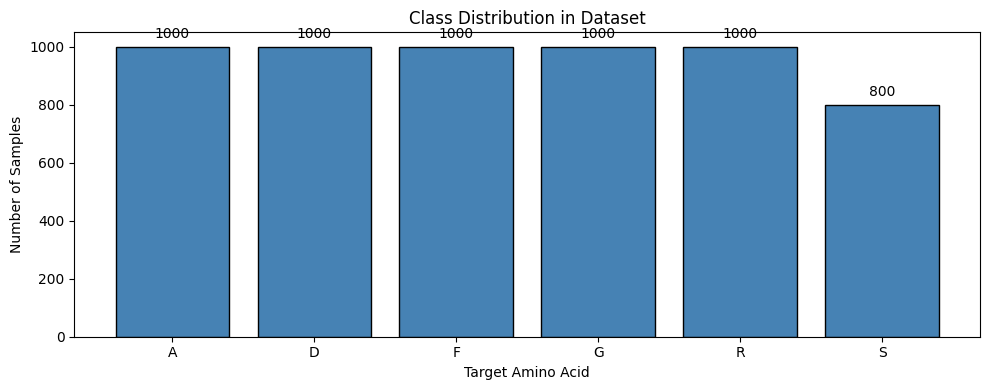

In [7]:
# Visualize class distribution
codes = list(class_dist.keys())
counts = [class_dist[c] for c in codes]

plt.figure(figsize=(10, 4))
plt.bar(codes, counts, color='steelblue', edgecolor='black')
plt.xlabel('Target Amino Acid')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
for i, (c, cnt) in enumerate(zip(codes, counts)):
    plt.text(i, cnt + 20, str(cnt), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Train/Validation Split and Data Augmentation

In [8]:
# Stratified train/val split (80/20)
labels = dataset.get_labels()
indices = list(range(len(dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f'Training samples: {len(train_indices)}')
print(f'Validation samples: {len(val_indices)}')

Training samples: 4640
Validation samples: 1160


In [9]:
# Data Augmentation for spectral data (reduces overfitting)
class SpectraAugmentation:
    """Apply augmentation transforms to spectra during training.
    
    Augmentations:
    - Gaussian noise: adds random noise to simulate measurement variability
    - Intensity scaling: randomly scales intensity to handle concentration variations
    - Baseline shift: adds random offset to handle baseline drift
    
    Args:
        noise_std: Standard deviation of Gaussian noise (default: 0.1)
        scale_range: Range for random intensity scaling (default: (0.9, 1.1))
        shift_range: Range for random baseline shift (default: (-0.1, 0.1))
    """
    
    def __init__(self, noise_std=0.1, scale_range=(0.9, 1.1), shift_range=(-0.1, 0.1)):
        self.noise_std = noise_std
        self.scale_range = scale_range
        self.shift_range = shift_range
    
    def __call__(self, spectrum):
        """Apply augmentation to a single spectrum.
        
        Args:
            spectrum: numpy array of shape (seq_len,)
        
        Returns:
            Augmented spectrum as numpy array
        """
        spectrum = spectrum.copy()
        
        # Add Gaussian noise
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, spectrum.shape)
            spectrum = spectrum + noise
        
        # Random intensity scaling
        if self.scale_range is not None:
            scale = np.random.uniform(self.scale_range[0], self.scale_range[1])
            spectrum = spectrum * scale
        
        # Random baseline shift
        if self.shift_range is not None:
            shift = np.random.uniform(self.shift_range[0], self.shift_range[1])
            spectrum = spectrum + shift
        
        return spectrum.astype(np.float32)


class AugmentedTwoChannelDataset(Dataset):
    """Wrapper that applies augmentation to a two-channel dataset subset during training.
    
    Args:
        subset: A Subset of TwoChannelDataset
        transform: SpectraAugmentation instance (applied to both channels)
        augment_zero_channel: Whether to augment the zero channel (default: False)
    """
    
    def __init__(self, subset, transform=None, augment_zero_channel=False):
        self.subset = subset
        self.transform = transform
        self.augment_zero_channel = augment_zero_channel
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        ch1, ch2, label = self.subset[idx]
        
        if self.transform:
            # Always augment channel 1
            ch1_np = ch1.numpy() if isinstance(ch1, torch.Tensor) else ch1
            ch1 = torch.tensor(self.transform(ch1_np), dtype=torch.float32)
            
            # Only augment channel 2 if it's not all zeros (or if augment_zero_channel is True)
            ch2_np = ch2.numpy() if isinstance(ch2, torch.Tensor) else ch2
            is_zero_channel = np.allclose(ch2_np, 0)
            
            if not is_zero_channel or self.augment_zero_channel:
                ch2 = torch.tensor(self.transform(ch2_np), dtype=torch.float32)
        
        return ch1, ch2, label


# Create augmentation with reduced intensity
augmentation = SpectraAugmentation(
    noise_std=0.02,           # Reduced: 0.1 → 0.02
    scale_range=(0.98, 1.02), # Reduced: (0.9, 1.1) → (0.98, 1.02)
    shift_range=(-0.02, 0.02) # Reduced: (-0.1, 0.1) → (-0.02, 0.02)
)

print("Data augmentation configured (reduced):")
print(f"  - Gaussian noise std: {augmentation.noise_std}")
print(f"  - Intensity scale range: {augmentation.scale_range}")
print(f"  - Baseline shift range: {augmentation.shift_range}")

Data augmentation configured (reduced):
  - Gaussian noise std: 0.02
  - Intensity scale range: (0.98, 1.02)
  - Baseline shift range: (-0.02, 0.02)


In [10]:
# Create data loaders with augmentation for training
batch_size = 32

# Create subsets
train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)

# Wrap training data with augmentation (validation stays clean)
train_dataset_aug = AugmentedTwoChannelDataset(
    train_subset, 
    transform=augmentation,
    augment_zero_channel=False  # Don't augment the zero channel for single AA samples
)

# Create data loaders
train_loader = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f'Training samples (with augmentation): {len(train_dataset_aug):,}')
print(f'Validation samples (no augmentation): {len(val_subset):,}')
print(f'\nBatch size: {batch_size}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

Training samples (with augmentation): 4,640
Validation samples (no augmentation): 1,160

Batch size: 32
Training batches: 145
Validation batches: 37


## Visualize Sample Pairs (Two-Channel View)

Showing 3 dipeptide pairs and 0 single AA samples


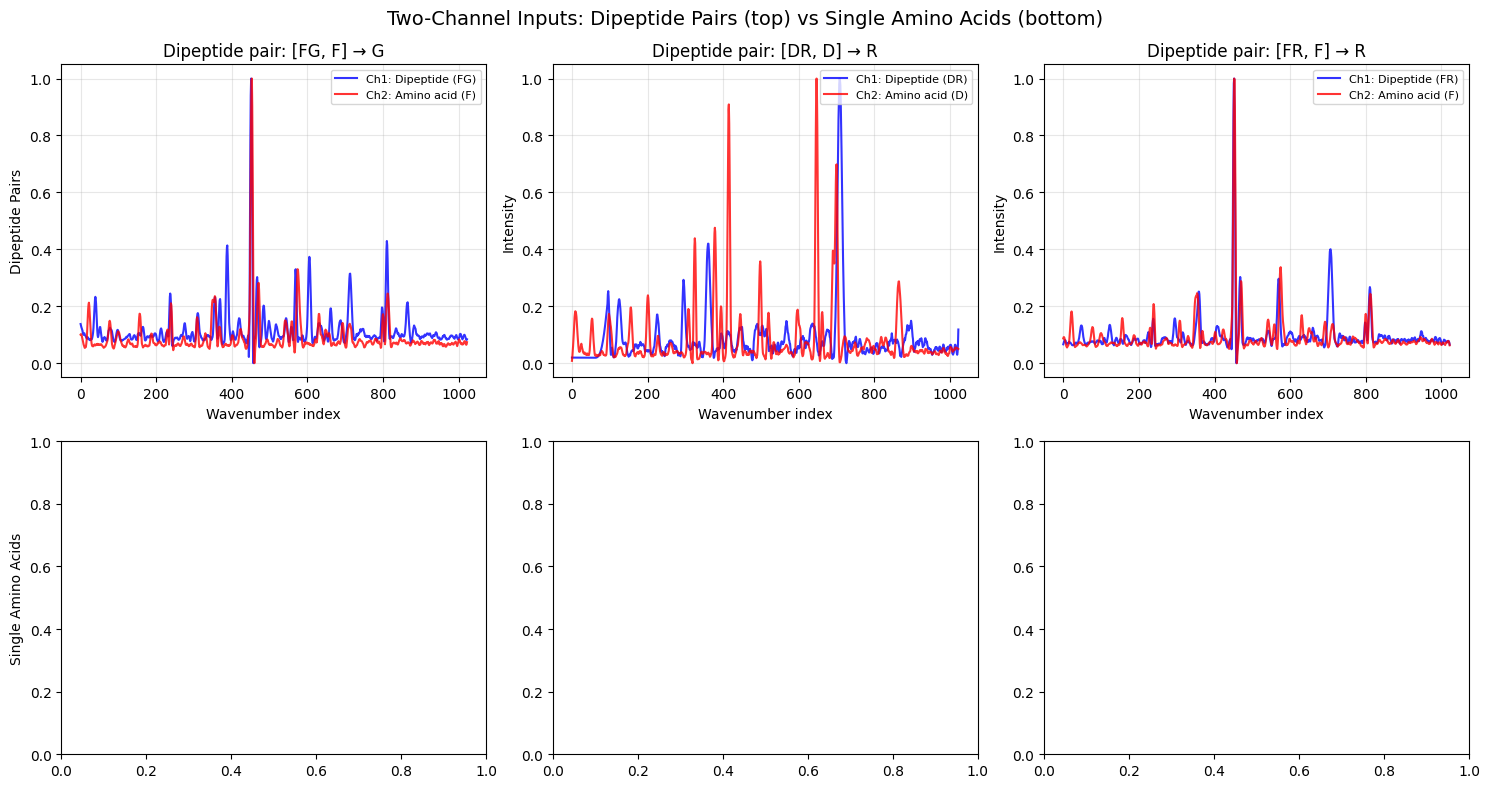

In [11]:
# Visualize sample pairs showing both types (dipeptide pairs and single amino acids)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Find indices for each type
dipeptide_indices = [i for i, info in enumerate(dataset.pair_info) if info[0] == 'dipeptide']
single_aa_indices = [i for i, info in enumerate(dataset.pair_info) if info[0] == 'single_aa']

# Top row: dipeptide pairs
print(f"Showing {min(3, len(dipeptide_indices))} dipeptide pairs and {min(3, len(single_aa_indices))} single AA samples")
for ax, idx in zip(axes[0], np.random.choice(dipeptide_indices, min(3, len(dipeptide_indices)), replace=False)):
    ch1, ch2, label = dataset[idx]
    sample_type, name1, name2, target = dataset.pair_info[idx]
    
    x = np.arange(len(ch1))
    ax.plot(x, ch1.numpy(), 'b-', label=f'Ch1: Dipeptide ({name1})', alpha=0.8)
    ax.plot(x, ch2.numpy(), 'r-', label=f'Ch2: Amino acid ({name2})', alpha=0.8)
    
    ax.set_title(f'Dipeptide pair: [{name1}, {name2}] → {target}')
    ax.set_xlabel('Wavenumber index')
    ax.set_ylabel('Intensity')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Bottom row: single amino acid samples
for ax, idx in zip(axes[1], np.random.choice(single_aa_indices, min(3, len(single_aa_indices)), replace=False)):
    ch1, ch2, label = dataset[idx]
    sample_type, name1, name2, target = dataset.pair_info[idx]
    
    x = np.arange(len(ch1))
    ax.plot(x, ch1.numpy(), 'b-', label=f'Ch1: Amino acid ({name1})', alpha=0.8)
    ax.plot(x, ch2.numpy(), 'r-', label=f'Ch2: Zeros', alpha=0.8)
    
    ax.set_title(f'Single AA: [{name1}, zeros] → {target}')
    ax.set_xlabel('Wavenumber index')
    ax.set_ylabel('Intensity')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Dipeptide Pairs')
axes[1, 0].set_ylabel('Single Amino Acids')

plt.suptitle('Two-Channel Inputs: Dipeptide Pairs (top) vs Single Amino Acids (bottom)', fontsize=14)
plt.tight_layout()
plt.show()

## Model Architecture (Two-Channel)

In [12]:
class TwoChannelClassifier(nn.Module):
    """Classifier using two-channel spectral input.
    
    Architecture: [S_dipeptide, S_aminoacid] (2 channels) -> CNN -> Transformer -> MLP -> classes
    
    Instead of computing the difference, this model takes both spectra as
    separate input channels, allowing the network to learn the relationship.
    
    Args:
        seq_length: Length of input spectra (default: 1023)
        d_model: Embedding dimension (default: 64)
        num_classes: Number of output classes (default: 6)
        dropout: Dropout rate (default: 0.3)
    """
    
    def __init__(self, seq_length=1023, d_model=64, num_classes=6, dropout=0.3):
        super().__init__()
        
        self.seq_length = seq_length
        self.d_model = d_model
        self.num_classes = num_classes
        
        # Feature extractor (CNN) - 2 input channels instead of 1
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=7, padding=3),  # 2 input channels
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(16, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Transformer encoder (lightweight: 1 layer)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout + 0.2),  # Higher dropout before final layer
            nn.Linear(d_model, num_classes),
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, spectrum_dipeptide, spectrum_aminoacid):
        """Forward pass.
        
        Args:
            spectrum_dipeptide: Dipeptide spectrum (batch, seq_len)
            spectrum_aminoacid: Amino acid spectrum (batch, seq_len)
        
        Returns:
            Logits of shape (batch, num_classes)
        """
        # Stack as 2-channel input instead of computing difference
        x = torch.stack([spectrum_dipeptide, spectrum_aminoacid], dim=1)  # (batch, 2, seq_len)
        
        # Extract features
        x = self.feature_extractor(x)  # (batch, d_model, seq_len)
        x = x.transpose(1, 2)  # (batch, seq_len, d_model)
        
        # Encode with transformer
        x = self.encoder(x)  # (batch, seq_len, d_model)
        
        # Global average pooling
        x = x.mean(dim=1)  # (batch, d_model)
        
        # Classify
        logits = self.classifier(x)  # (batch, num_classes)
        
        return logits
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [13]:
# Create model
model = TwoChannelClassifier(
    seq_length=1023,
    d_model=64,
    num_classes=len(AMINO_ACID_CODES),
    dropout=0.3
).to(device)

print(f'Model parameters: {model.count_parameters():,}')
print(f'\nModel architecture:')
print(model)

Model parameters: 43,606

Model architecture:
TwoChannelClassifier(
  (feature_extractor): Sequential(
    (0): Conv1d(2, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(16, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=Tru

C:\Users\mfarzi\miniconda3\envs\spectra\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Training

In [14]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=20,
                resume_checkpoint=None):
    """Train the model with early stopping and optional resume.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        epochs: Maximum number of epochs
        lr: Learning rate
        patience: Early stopping patience
        resume_checkpoint: Path to checkpoint to resume from (optional)
    
    Returns:
        Training history dictionary
    """
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    # Early stopping
    best_val_loss = float('inf')
    best_val_acc = 0
    epochs_without_improvement = 0
    start_epoch = 0
    
    # Resume from checkpoint if provided
    if resume_checkpoint and Path(resume_checkpoint).exists():
        checkpoint = torch.load(resume_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['val_loss']
        best_val_acc = checkpoint['val_acc']
        print(f'Resuming from epoch {start_epoch}')
        print(f'Previous best: val_loss={best_val_loss:.4f}, val_acc={best_val_acc:.2f}%\n')
    
    # Ensure checkpoint directory exists
    Path('checkpoints').mkdir(exist_ok=True)
    
    for epoch in range(start_epoch, epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for dip, aa, labels in train_loader:
            dip = dip.to(device)
            aa = aa.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(dip, aa)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for dip, aa, labels in val_loader:
                dip = dip.to(device)
                aa = aa.to(device)
                labels = labels.to(device)
                
                outputs = model(dip, aa)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, 'checkpoints/sequence_classifier_2ch_best.pt')
        else:
            epochs_without_improvement += 1
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == start_epoch:
            print(f'Epoch {epoch+1:3d}/{epochs}: '
                  f'Train Loss={train_loss:.4f}, '
                  f'Val Loss={val_loss:.4f}, '
                  f'Val Acc={val_acc:.2f}%, '
                  f'LR={current_lr:.2e}')
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f'\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
            break
    
    print(f'\nBest validation loss: {best_val_loss:.4f}')
    print(f'Best validation accuracy: {best_val_acc:.2f}%')
    
    return history

In [15]:
# Train the model (set resume_checkpoint=None to start fresh with new data)
print('Starting training...')
print('Model: TwoChannelClassifier (2-channel input)\n')

history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=0.001,
    patience=100,  # Disabled early stopping
    resume_checkpoint=None  # Start fresh (data changed)
)

Starting training...
Model: TwoChannelClassifier (2-channel input)

Epoch   1/100: Train Loss=1.5798, Val Loss=1.9585, Val Acc=37.50%, LR=1.00e-03
Epoch  10/100: Train Loss=0.3615, Val Loss=0.2979, Val Acc=91.81%, LR=1.00e-03
Epoch  20/100: Train Loss=0.1859, Val Loss=0.1932, Val Acc=96.72%, LR=1.00e-03
Epoch  30/100: Train Loss=0.1195, Val Loss=0.1237, Val Acc=97.16%, LR=1.00e-03
Epoch  40/100: Train Loss=0.1125, Val Loss=0.1264, Val Acc=97.84%, LR=1.00e-03


KeyboardInterrupt: 

NameError: name 'history' is not defined

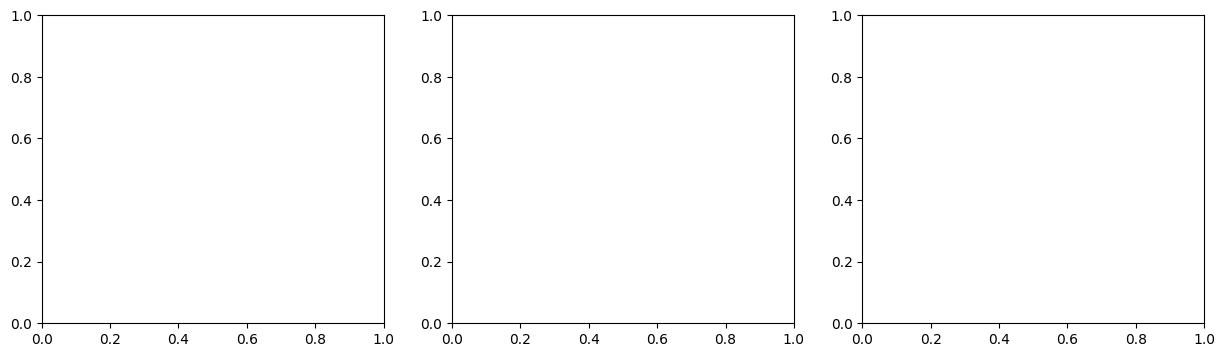

In [16]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[1].axhline(y=100/len(AMINO_ACID_CODES), color='gray', linestyle='--', label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], label='Learning Rate', color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [17]:
# Load best model
checkpoint = torch.load('checkpoints/sequence_classifier_2ch_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 38
Best validation accuracy: 98.28%


In [18]:
# Evaluate on validation set
model.eval()
all_predictions = []
all_labels = []
all_probs = []

with torch.no_grad():
    for dip, aa, labels in val_loader:
        dip = dip.to(device)
        aa = aa.to(device)
        
        outputs = model(dip, aa)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Overall accuracy
accuracy = 100.0 * np.mean(all_predictions == all_labels)
print(f'Validation Accuracy: {accuracy:.2f}%')
print(f'Random baseline: {100/len(AMINO_ACID_CODES):.2f}%')

Validation Accuracy: 98.28%
Random baseline: 16.67%


In [19]:
# Classification report
target_names = [f'{code} ({CODE_TO_NAME[code]})' for code in AMINO_ACID_CODES]
print('\nClassification Report:')
print('=' * 60)
print(classification_report(all_labels, all_predictions, target_names=target_names, digits=3))


Classification Report:
                   precision    recall  f1-score   support

      A (Alanine)      0.970     0.980     0.975       200
D (Aspartic acid)      0.965     0.970     0.968       200
F (Phenylalanine)      0.995     1.000     0.998       200
      G (Glycine)      0.995     0.975     0.985       200
     R (Arginine)      0.985     0.990     0.988       200
       S (Serine)      0.987     0.981     0.984       160

         accuracy                          0.983      1160
        macro avg      0.983     0.983     0.983      1160
     weighted avg      0.983     0.983     0.983      1160



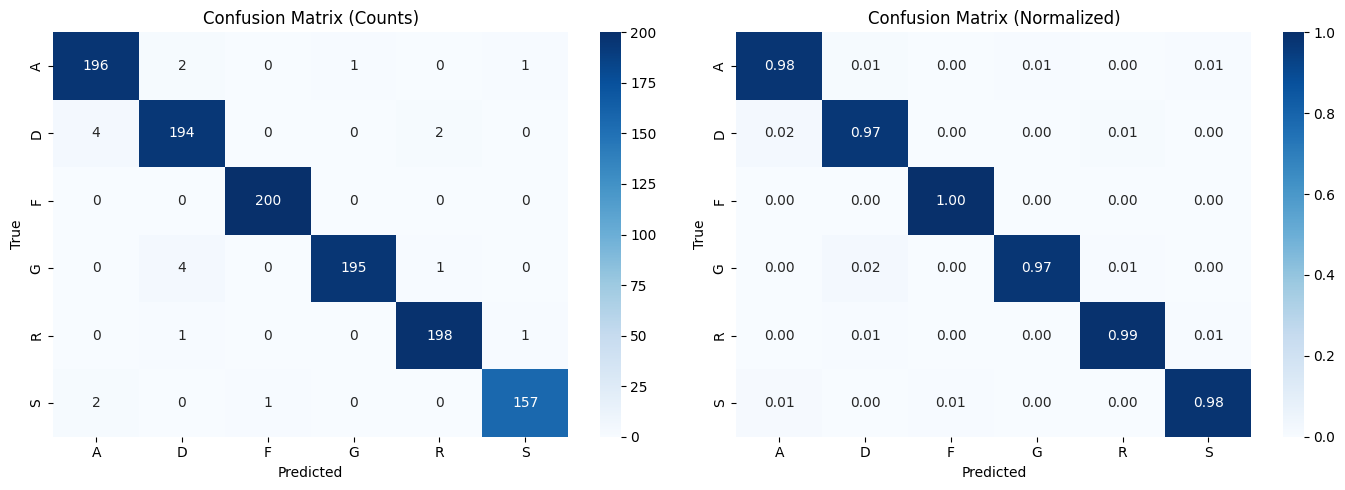

In [20]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

In [21]:
# Per-class accuracy
print('\nPer-class accuracy:')
for i, code in enumerate(AMINO_ACID_CODES):
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_acc = 100.0 * (all_predictions[class_mask] == i).mean()
        print(f'  {code} ({CODE_TO_NAME[code]}): {class_acc:.2f}% ({class_mask.sum()} samples)')


Per-class accuracy:
  A (Alanine): 98.00% (200 samples)
  D (Aspartic acid): 97.00% (200 samples)
  F (Phenylalanine): 100.00% (200 samples)
  G (Glycine): 97.50% (200 samples)
  R (Arginine): 99.00% (200 samples)
  S (Serine): 98.12% (160 samples)


## Visualize Predictions

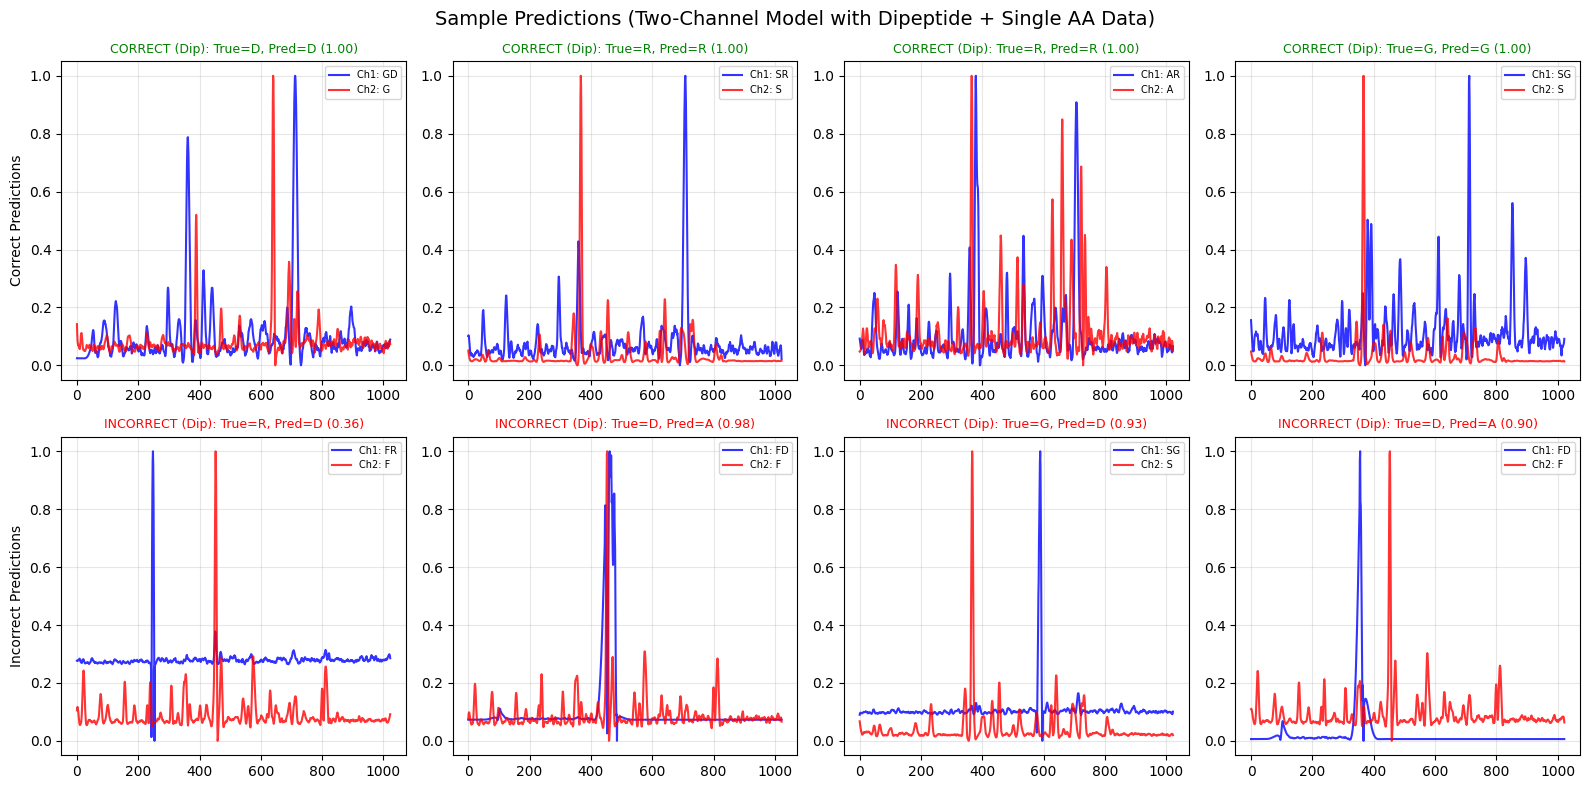

In [22]:
# Visualize some correct and incorrect predictions
correct_mask = all_predictions == all_labels
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Show 4 correct predictions
correct_indices = np.where(correct_mask)[0]
for ax, idx in zip(axes[0], np.random.choice(correct_indices, min(4, len(correct_indices)), replace=False)):
    # Get the actual data from validation set
    val_idx = val_indices[idx]
    ch1, ch2, label = dataset[val_idx]
    sample_type, name1, name2, target = dataset.pair_info[val_idx]
    pred = all_predictions[idx]
    prob = all_probs[idx][pred]
    
    ax.plot(ch1.numpy(), 'b-', label=f'Ch1: {name1}', alpha=0.8)
    ax.plot(ch2.numpy(), 'r-', label=f'Ch2: {name2}', alpha=0.8)
    
    title_prefix = 'Dip' if sample_type == 'dipeptide' else 'AA'
    ax.set_title(f'CORRECT ({title_prefix}): True={IDX_TO_CODE[label.item()]}, Pred={IDX_TO_CODE[pred]} ({prob:.2f})', 
                 color='green', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

# Show 4 incorrect predictions
incorrect_indices = np.where(incorrect_mask)[0]
if len(incorrect_indices) > 0:
    for ax, idx in zip(axes[1], np.random.choice(incorrect_indices, min(4, len(incorrect_indices)), replace=False)):
        val_idx = val_indices[idx]
        ch1, ch2, label = dataset[val_idx]
        sample_type, name1, name2, target = dataset.pair_info[val_idx]
        pred = all_predictions[idx]
        prob = all_probs[idx][pred]
        
        ax.plot(ch1.numpy(), 'b-', label=f'Ch1: {name1}', alpha=0.8)
        ax.plot(ch2.numpy(), 'r-', label=f'Ch2: {name2}', alpha=0.8)
        
        title_prefix = 'Dip' if sample_type == 'dipeptide' else 'AA'
        ax.set_title(f'INCORRECT ({title_prefix}): True={IDX_TO_CODE[label.item()]}, Pred={IDX_TO_CODE[pred]} ({prob:.2f})', 
                     color='red', fontsize=9)
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)
else:
    for ax in axes[1]:
        ax.text(0.5, 0.5, 'No incorrect predictions!', ha='center', va='center', fontsize=12)
        ax.set_title('No errors', color='green')

axes[0, 0].set_ylabel('Correct Predictions')
axes[1, 0].set_ylabel('Incorrect Predictions')

plt.suptitle('Sample Predictions (Two-Channel Model with Dipeptide + Single AA Data)', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a neural network classifier using **two-channel spectral input** for amino acid classification.

### Training Data Types:
1. **Dipeptide pairs**: (dipeptide XY, amino acid X) → predict Y
   - Channel 1: Dipeptide spectrum
   - Channel 2: Amino acid spectrum
   
2. **Single amino acids**: (amino acid X, zeros) → predict X
   - Channel 1: Amino acid spectrum
   - Channel 2: All zeros

### Evaluation Data Types:
3. **Tripeptide-Dipeptide pairs** (transfer evaluation): (tripeptide XYZ, dipeptide XY) → predict Z
   - Channel 1: Tripeptide spectrum
   - Channel 2: Dipeptide spectrum

### Key Results:
- **Task**: Classify amino acids from two-channel spectral input
- **Classes**: 6 amino acids (A, D, F, G, R, S)
- **Model**: TwoChannelClassifier (CNN + Transformer)
- **Architecture**: [Ch1, Ch2] (2 channels) → CNN features → Transformer encoder → Classification head

### Model Design Choices:
1. **Two-channel input** allows the model to learn relationships between spectra
2. **Mixed training data** (dipeptide pairs + single amino acids) improves generalization
3. **Zero channel** for single amino acids teaches the model to recognize amino acids independently
4. **Same lightweight architecture** (CNN + single transformer layer)

### Transfer Learning Evaluation:
The model trained on (dipeptide, amino acid) pairs is evaluated on (tripeptide, dipeptide) pairs without any fine-tuning. This tests whether the learned spectral relationship patterns generalize to longer peptide sequences.

### Next Steps:
- Fine-tune the model on tripeptide data
- Analyze error patterns between validation and tripeptide evaluation
- Experiment with including tripeptide data in training

## Evaluation on Tripeptide-Dipeptide Data

Test the model's generalization on tripeptide-dipeptide pairs:
- **Input**: (tripeptide XYZ, dipeptide XY) as 2 channels
- **Target**: Predict Z (the third amino acid)

This tests whether patterns learned from (dipeptide, amino acid) transfer to (tripeptide, dipeptide).

In [23]:
# Load tripeptide data
tripeptide_dir = Path('./data/processed/tripeptides')

tripeptide_data = {}
print('Loading tripeptide data...')
for folder in sorted(tripeptide_dir.iterdir()):
    if folder.is_dir():
        clean_data_path = folder / 'clean_data.npz'
        if clean_data_path.exists():
            data = np.load(clean_data_path, allow_pickle=True)
            intensities = data['intensities']
            n_spectra = intensities.shape[0]
            if n_spectra >= MIN_SPECTRA:
                tripeptide_data[folder.name] = intensities
                print(f'  {folder.name}: {n_spectra} spectra')
            else:
                print(f'  {folder.name}: {n_spectra} spectra (skipped, < {MIN_SPECTRA})')

print(f'\nLoaded {len(tripeptide_data)} tripeptides with >= {MIN_SPECTRA} spectra')

Loading tripeptide data...
  ARS: 29 spectra
  ASF: 707 spectra
  DFA: 264 spectra
  DFS: 1301 spectra
  DRF: 147 spectra
  FDR: 250 spectra
  FGA: 293 spectra
  FGS: 838 spectra
  FSA: 660 spectra
  FSG: 35 spectra
  GAR: 189 spectra
  RSA: 9 spectra
  RSF: 82 spectra
  SDF: 103 spectra
  SGF: 272 spectra
  SRA: 1470 spectra

Loaded 16 tripeptides with >= 5 spectra


In [24]:
# Create tripeptide-dipeptide evaluation dataset
class TripeptideDipeptideDataset(Dataset):
    """Dataset for tripeptide-dipeptide pairs (evaluation only).
    
    For each tripeptide XYZ:
    - Channel 1: spectrum from tripeptide XYZ
    - Channel 2: spectrum from dipeptide XY (first two letters)
    - Label: index of Z (third letter) - the "missing" amino acid
    """
    
    def __init__(self, tripeptide_data, dipeptide_data, samples_per_pair=None):
        self.pairs = []
        self.pair_info = []
        
        print("Creating tripeptide-dipeptide pairs...")
        for tripeptide_name, tripeptide_spectra in tripeptide_data.items():
            xy = tripeptide_name[:2]  # XY in XYZ (dipeptide)
            z = tripeptide_name[2]    # Z in XYZ (target to predict)
            
            # Skip if dipeptide data not available
            if xy not in dipeptide_data:
                print(f'  Skipping {tripeptide_name}: dipeptide {xy} not available')
                continue
            
            # Skip if target class not in our label set
            if z not in CODE_TO_IDX:
                print(f'  Skipping {tripeptide_name}: target {z} not in class set')
                continue
            
            dipeptide_spectra = dipeptide_data[xy]
            label = CODE_TO_IDX[z]
            
            # Determine number of pairs
            n_tripeptide = len(tripeptide_spectra)
            n_dipeptide = len(dipeptide_spectra)
            n_pairs = min(n_tripeptide, n_dipeptide)
            if samples_per_pair is not None:
                n_pairs = min(n_pairs, samples_per_pair)
            
            # Random sampling
            tri_indices = np.random.choice(n_tripeptide, n_pairs, replace=False)
            dip_indices = np.random.choice(n_dipeptide, n_pairs, replace=False)
            
            for ti, di in zip(tri_indices, dip_indices):
                self.pairs.append((
                    tripeptide_spectra[ti],  # Channel 1: tripeptide
                    dipeptide_spectra[di],    # Channel 2: dipeptide
                    label
                ))
                self.pair_info.append(('tripeptide', tripeptide_name, xy, z))
            
            print(f'  {tripeptide_name} - {xy} → {z}: {n_pairs} pairs')
        
        print(f'\nTotal tripeptide-dipeptide pairs: {len(self.pairs)}')
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        tri, dip, label = self.pairs[idx]
        return (
            torch.tensor(tri, dtype=torch.float32),
            torch.tensor(dip, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )
    
    def get_labels(self):
        return [p[2] for p in self.pairs]
    
    def get_class_distribution(self):
        labels = self.get_labels()
        unique, counts = np.unique(labels, return_counts=True)
        return {IDX_TO_CODE[u]: c for u, c in zip(unique, counts)}

# Create tripeptide evaluation dataset
tripeptide_eval_dataset = TripeptideDipeptideDataset(
    tripeptide_data,
    dipeptide_data,
    samples_per_pair=50  # Limit samples per pair
)

# Show class distribution
tri_class_dist = tripeptide_eval_dataset.get_class_distribution()
print('\nTripeptide evaluation class distribution:')
for code, count in sorted(tri_class_dist.items()):
    print(f'  {code} ({CODE_TO_NAME[code]}): {count} samples')

Creating tripeptide-dipeptide pairs...
  ARS - AR → S: 29 pairs
  ASF - AS → F: 50 pairs
  DFA - DF → A: 50 pairs
  DFS - DF → S: 50 pairs
  DRF - DR → F: 50 pairs
  FDR - FD → R: 50 pairs
  FGA - FG → A: 50 pairs
  FGS - FG → S: 50 pairs
  FSA - FS → A: 50 pairs
  FSG - FS → G: 35 pairs
  GAR - GA → R: 50 pairs
  RSA - RS → A: 9 pairs
  RSF - RS → F: 50 pairs
  SDF - SD → F: 50 pairs
  SGF - SG → F: 50 pairs
  SRA - SR → A: 50 pairs

Total tripeptide-dipeptide pairs: 723

Tripeptide evaluation class distribution:
  A (Alanine): 209 samples
  F (Phenylalanine): 250 samples
  G (Glycine): 35 samples
  R (Arginine): 100 samples
  S (Serine): 129 samples


In [25]:
# Create data loader for tripeptide evaluation
tripeptide_loader = DataLoader(tripeptide_eval_dataset, batch_size=32, shuffle=False)

# Evaluate model on tripeptide-dipeptide pairs
model.eval()
tri_predictions = []
tri_labels = []
tri_probs = []

with torch.no_grad():
    for tri, dip, labels in tripeptide_loader:
        tri = tri.to(device)
        dip = dip.to(device)
        
        outputs = model(tri, dip)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        tri_predictions.extend(predicted.cpu().numpy())
        tri_labels.extend(labels.numpy())
        tri_probs.extend(probs.cpu().numpy())

tri_predictions = np.array(tri_predictions)
tri_labels = np.array(tri_labels)
tri_probs = np.array(tri_probs)

# Overall accuracy
tri_accuracy = 100.0 * np.mean(tri_predictions == tri_labels)
print(f'Tripeptide-Dipeptide Evaluation Accuracy: {tri_accuracy:.2f}%')
print(f'Random baseline: {100/len(AMINO_ACID_CODES):.2f}%')

Tripeptide-Dipeptide Evaluation Accuracy: 32.64%
Random baseline: 16.67%


In [26]:
# Classification report for tripeptide evaluation
print('\nTripeptide-Dipeptide Classification Report:')
print('=' * 70)
# Only include classes that have samples in tripeptide data
tri_present_classes = sorted(set(tri_labels))
tri_target_names = [f'{IDX_TO_CODE[i]} ({CODE_TO_NAME[IDX_TO_CODE[i]]})' for i in tri_present_classes]
print(classification_report(
    tri_labels, 
    tri_predictions, 
    labels=tri_present_classes,
    target_names=tri_target_names, 
    digits=3,
    zero_division=0
))


Tripeptide-Dipeptide Classification Report:
                   precision    recall  f1-score   support

      A (Alanine)      0.235     0.038     0.066       209
F (Phenylalanine)      0.876     0.536     0.665       250
      G (Glycine)      0.014     0.057     0.022        35
     R (Arginine)      0.922     0.470     0.623       100
       S (Serine)      0.196     0.349     0.251       129

        micro avg      0.386     0.326     0.354       723
        macro avg      0.448     0.290     0.325       723
     weighted avg      0.534     0.326     0.381       723



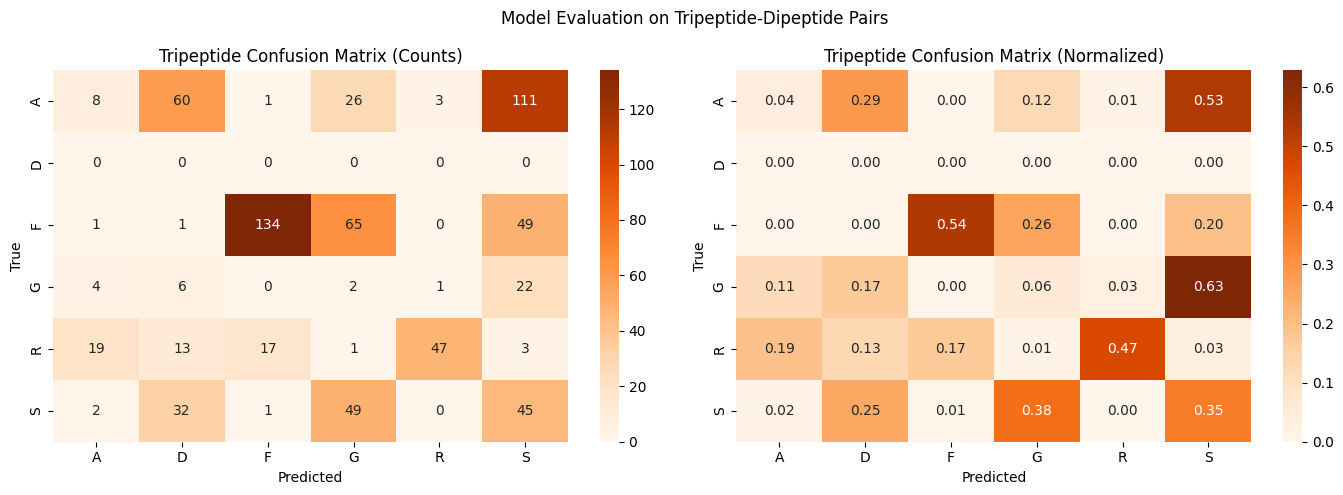

In [27]:
# Confusion matrix for tripeptide evaluation (6-class space)
tri_cm = confusion_matrix(tri_labels, tri_predictions, labels=list(range(6)))

# Normalize (handle rows with no samples)
tri_cm_normalized = np.zeros_like(tri_cm, dtype=float)
for i in range(6):
    if tri_cm[i].sum() > 0:
        tri_cm_normalized[i] = tri_cm[i].astype('float') / tri_cm[i].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(tri_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Tripeptide Confusion Matrix (Counts)')

# Normalized
sns.heatmap(tri_cm_normalized, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=AMINO_ACID_CODES, yticklabels=AMINO_ACID_CODES)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Tripeptide Confusion Matrix (Normalized)')

plt.suptitle('Model Evaluation on Tripeptide-Dipeptide Pairs', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
# Per-class accuracy for tripeptide evaluation
print('\nTripeptide per-class accuracy:')
for i, code in enumerate(AMINO_ACID_CODES):
    class_mask = tri_labels == i
    n_samples = class_mask.sum()
    if n_samples > 0:
        class_acc = 100.0 * (tri_predictions[class_mask] == i).mean()
        print(f'  {code} ({CODE_TO_NAME[code]}): {class_acc:.2f}% ({n_samples} samples)')
    else:
        print(f'  {code} ({CODE_TO_NAME[code]}): N/A (no samples)')


Tripeptide per-class accuracy:
  A (Alanine): 3.83% (209 samples)
  D (Aspartic acid): N/A (no samples)
  F (Phenylalanine): 53.60% (250 samples)
  G (Glycine): 5.71% (35 samples)
  R (Arginine): 47.00% (100 samples)
  S (Serine): 34.88% (129 samples)


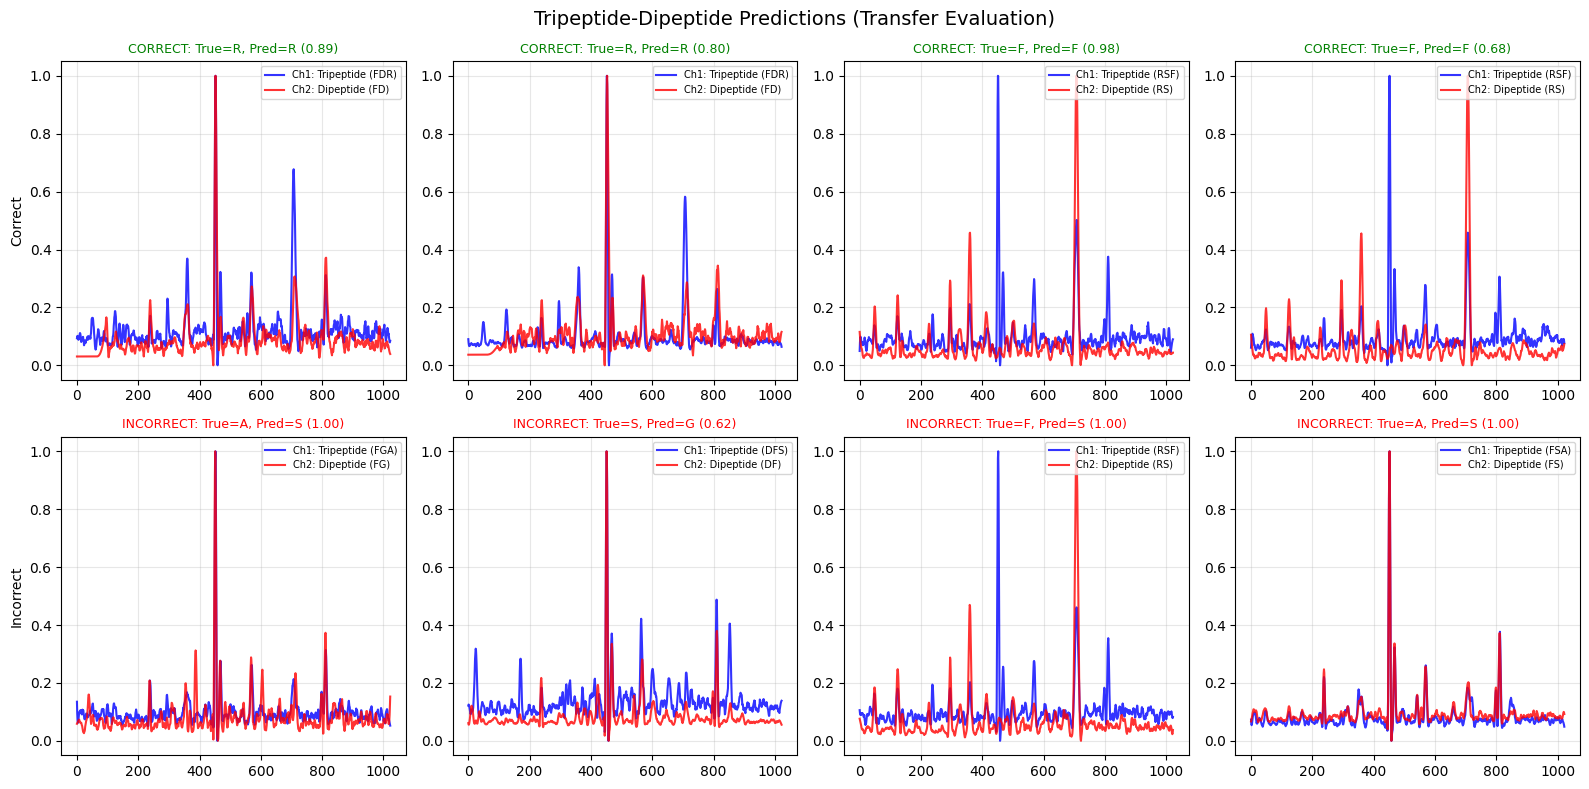

In [29]:
# Visualize tripeptide-dipeptide predictions
tri_correct_mask = tri_predictions == tri_labels
tri_incorrect_mask = ~tri_correct_mask

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Show 4 correct predictions
tri_correct_indices = np.where(tri_correct_mask)[0]
if len(tri_correct_indices) > 0:
    for ax, idx in zip(axes[0], np.random.choice(tri_correct_indices, min(4, len(tri_correct_indices)), replace=False)):
        ch1, ch2, label = tripeptide_eval_dataset[idx]
        sample_type, name1, name2, target = tripeptide_eval_dataset.pair_info[idx]
        pred = tri_predictions[idx]
        prob = tri_probs[idx][pred]
        
        ax.plot(ch1.numpy(), 'b-', label=f'Ch1: Tripeptide ({name1})', alpha=0.8)
        ax.plot(ch2.numpy(), 'r-', label=f'Ch2: Dipeptide ({name2})', alpha=0.8)
        ax.set_title(f'CORRECT: True={target}, Pred={IDX_TO_CODE[pred]} ({prob:.2f})', 
                     color='green', fontsize=9)
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)
else:
    for ax in axes[0]:
        ax.text(0.5, 0.5, 'No correct predictions', ha='center', va='center')

# Show 4 incorrect predictions
tri_incorrect_indices = np.where(tri_incorrect_mask)[0]
if len(tri_incorrect_indices) > 0:
    for ax, idx in zip(axes[1], np.random.choice(tri_incorrect_indices, min(4, len(tri_incorrect_indices)), replace=False)):
        ch1, ch2, label = tripeptide_eval_dataset[idx]
        sample_type, name1, name2, target = tripeptide_eval_dataset.pair_info[idx]
        pred = tri_predictions[idx]
        prob = tri_probs[idx][pred]
        
        ax.plot(ch1.numpy(), 'b-', label=f'Ch1: Tripeptide ({name1})', alpha=0.8)
        ax.plot(ch2.numpy(), 'r-', label=f'Ch2: Dipeptide ({name2})', alpha=0.8)
        ax.set_title(f'INCORRECT: True={target}, Pred={IDX_TO_CODE[pred]} ({prob:.2f})', 
                     color='red', fontsize=9)
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.3)
else:
    for ax in axes[1]:
        ax.text(0.5, 0.5, 'No incorrect predictions!', ha='center', va='center', fontsize=12)
        ax.set_title('No errors', color='green')

axes[0, 0].set_ylabel('Correct')
axes[1, 0].set_ylabel('Incorrect')

plt.suptitle('Tripeptide-Dipeptide Predictions (Transfer Evaluation)', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# Summary comparison
print('=' * 70)
print('EVALUATION SUMMARY')
print('=' * 70)
print(f'\nModel: TwoChannelClassifier (trained on dipeptide-AA pairs + single AAs)')
print(f'Total parameters: {model.count_parameters():,}')
print()
print('Validation Set (dipeptide-AA pairs + single AAs):')
print(f'  Accuracy: {accuracy:.2f}%')
print(f'  Samples: {len(all_labels)}')
print()
print('Tripeptide-Dipeptide Pairs (transfer evaluation):')
print(f'  Accuracy: {tri_accuracy:.2f}%')
print(f'  Samples: {len(tri_labels)}')
print()
print(f'Random baseline (6 classes): {100/6:.2f}%')
print('=' * 70)

EVALUATION SUMMARY

Model: TwoChannelClassifier (trained on dipeptide-AA pairs + single AAs)
Total parameters: 43,606

Validation Set (dipeptide-AA pairs + single AAs):
  Accuracy: 98.28%
  Samples: 1160

Tripeptide-Dipeptide Pairs (transfer evaluation):
  Accuracy: 32.64%
  Samples: 723

Random baseline (6 classes): 16.67%
